# Task 2: rPPG signal extraction and baseline evaluation

Self-contained notebook for Task 2. It reads every processed sample from the current Task 1 manifest, extracts ROI RGB traces from source videos, runs Green/CHROM/POS baselines, evaluates heart-rate estimates against normalized Task 1 ground truth, saves standardized artifacts for Task 3, and shows a representative visualization in the notebook.


## Standardized outputs

Dataset-level outputs:

- `outputs/task2_signals/task2_dataset_manifest.json`
- `outputs/task2_signals/task2_metrics_summary.csv`

Per-sample outputs:

- `outputs/task2_signals/<split>/<sample_id>/signals.npz`
- `outputs/task2_signals/<split>/<sample_id>/metadata.json`
- `outputs/task2_signals/<split>/<sample_id>/metrics.json`
- `outputs/task2_signals/<split>/<sample_id>/metrics.csv`
- `outputs/task2_signals/<split>/<sample_id>/visualization.png`


In [23]:
from __future__ import annotations

import csv
import json
import math
from pathlib import Path
from typing import Any

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.signal as sp_signal
from IPython.display import Image, display
from scipy.interpolate import interp1d
from scipy.stats import pearsonr
from tqdm.auto import tqdm

SCHEMA_VERSION = "task2_rppg_v1"
METHODS = ("green", "chrom", "pos")
ROI_NAMES_FALLBACK = ("forehead", "left_cheek", "right_cheek")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TASK1_MANIFEST_PATH = PROJECT_ROOT / "outputs/task1_preprocessing/task1_dataset_manifest.json"
TASK2_OUTPUT_ROOT = PROJECT_ROOT / "outputs/task2_signals"

PROCESS_ALL_TASK1_OUTPUTS = True
BATCH_LIMIT: int | None = None
MAX_FRAMES_PER_SAMPLE: int | None = None
WINDOW_SEC = 30.0
STEP_SEC = 1.0
HR_MIN_BPM = 42.0
HR_MAX_BPM = 210.0
SAVE_FIGURES = True
SHOW_SAMPLE_VISUALIZATION = True
PROGRESS = True

TASK2_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "schema_version": SCHEMA_VERSION,
    "task1_manifest_path": TASK1_MANIFEST_PATH.relative_to(PROJECT_ROOT).as_posix(),
    "task2_output_root": TASK2_OUTPUT_ROOT.relative_to(PROJECT_ROOT).as_posix(),
    "process_all_task1_outputs": PROCESS_ALL_TASK1_OUTPUTS,
    "batch_limit": BATCH_LIMIT,
    "max_frames_per_sample": MAX_FRAMES_PER_SAMPLE,
    "window_sec": WINDOW_SEC,
    "step_sec": STEP_SEC,
    "hr_min_bpm": HR_MIN_BPM,
    "hr_max_bpm": HR_MAX_BPM,
    "save_figures": SAVE_FIGURES,
}

display(pd.DataFrame([CONFIG]).T.rename(columns={0: "value"}))


,value
schema_version,task2_rppg_v1
task1_manifest_path,outputs/task1_preprocessing/task1_dataset_mani...
task2_output_root,outputs/task2_signals
process_all_task1_outputs,True
batch_limit,None
max_frames_per_sample,None
window_sec,30.0
step_sec,1.0
hr_min_bpm,42.0
hr_max_bpm,210.0


In [24]:
def load_json(path: Path) -> dict[str, Any]:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def to_builtin(value: Any) -> Any:
    if isinstance(value, np.generic):
        return to_builtin(value.item())
    if isinstance(value, np.ndarray):
        return to_builtin(value.tolist())
    if isinstance(value, Path):
        return value.as_posix()
    if isinstance(value, float):
        return value if math.isfinite(value) else None
    if isinstance(value, dict):
        return {str(k): to_builtin(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_builtin(v) for v in value]
    return value


def write_json(path: Path, payload: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(to_builtin(payload), f, ensure_ascii=False, indent=2, allow_nan=False)


def project_relpath(path: Path) -> str:
    try:
        return path.resolve().relative_to(PROJECT_ROOT).as_posix()
    except ValueError:
        return path.resolve().as_posix()


def output_relpath(path: Path) -> str:
    try:
        return path.resolve().relative_to(TASK2_OUTPUT_ROOT).as_posix()
    except ValueError:
        return path.resolve().as_posix()


def resolve_project_path(path_text: str | Path) -> Path:
    path = Path(path_text)
    return (PROJECT_ROOT / path).resolve() if not path.is_absolute() else path.resolve()


def resolve_task1_output_path(path_text: str | Path) -> Path:
    path = Path(path_text)
    task1_root = TASK1_MANIFEST_PATH.parent
    return (task1_root / path).resolve() if not path.is_absolute() else path.resolve()


def write_metrics_csv(path: Path, metrics: dict[str, dict[str, float | int]]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    fieldnames = ("method", "mae_bpm", "rmse_bpm", "pearson_r", "bias_bpm", "snr_db", "n_windows")
    with path.open("w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for method in METHODS:
            writer.writerow({"method": method, **to_builtin(metrics[method])})


def write_summary_csv(path: Path, items: list[dict[str, Any]]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    fieldnames = ("sample_id", "split", "method", "mae_bpm", "rmse_bpm", "pearson_r", "bias_bpm", "snr_db", "n_windows")
    with path.open("w", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for item in items:
            if item.get("status") != "processed":
                continue
            for method in METHODS:
                writer.writerow({"sample_id": item["sample_id"], "split": item["split"], "method": method, **to_builtin(item["metrics"][method])})


In [25]:
def load_task1_manifest(path: Path) -> dict[str, Any]:
    manifest = load_json(path)
    if not isinstance(manifest.get("items"), list):
        raise KeyError("Task 1 manifest must contain an 'items' list.")
    return manifest


def select_task1_items(manifest: dict[str, Any]) -> list[dict[str, Any]]:
    items = [item for item in manifest["items"] if item.get("status") == "processed"]
    if not PROCESS_ALL_TASK1_OUTPUTS:
        raise ValueError("This notebook is configured to process all Task 1 outputs. Set PROCESS_ALL_TASK1_OUTPUTS=True.")
    return items[:BATCH_LIMIT] if BATCH_LIMIT is not None else items


def load_task1_arrays(path: Path) -> dict[str, np.ndarray]:
    with np.load(path, allow_pickle=True) as data:
        arrays = {key: data[key] for key in data.files}
    required = {"frame_indices", "roi_masks", "valid"}
    missing = required.difference(arrays)
    if missing:
        raise KeyError(f"Task 1 ROI npz is missing required arrays: {sorted(missing)}")
    return arrays


def get_roi_names(arrays: dict[str, np.ndarray], metadata: dict[str, Any]) -> np.ndarray:
    if "roi_names" in arrays:
        return arrays["roi_names"].astype(object)
    return np.array(metadata.get("roi_names", ROI_NAMES_FALLBACK), dtype=object)


def load_ground_truth_npz(path: Path) -> dict[str, np.ndarray]:
    required = ("timestamps", "heart_rate_bpm", "ppg_signal", "ppg_timestamps", "spo2_percent")
    with np.load(path, allow_pickle=True) as data:
        missing = set(required).difference(data.files)
        if missing:
            raise KeyError(f"Ground truth npz is missing required arrays: {sorted(missing)}")
        return {key: np.atleast_1d(np.asarray(data[key]).squeeze()).astype(np.float64) for key in required}


def extract_mean_rgb(
    video_path: Path,
    arrays: dict[str, np.ndarray],
    metadata: dict[str, Any],
    max_frames: int | None = None,
    progress: bool = False,
) -> dict[str, np.ndarray]:
    frame_indices = arrays["frame_indices"].astype(np.int64)
    roi_masks = arrays["roi_masks"].astype(bool)
    valid = arrays["valid"].astype(bool)
    if max_frames is not None:
        frame_indices = frame_indices[:max_frames]
        roi_masks = roi_masks[:max_frames]
        valid = valid[:max_frames]

    fps = float(metadata["video"]["fps"])
    timestamps = frame_indices.astype(np.float64) / fps
    mean_rgb = np.full((len(frame_indices), roi_masks.shape[1], 3), np.nan, dtype=np.float32)

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open source video: {video_path}")

    iterator = range(len(frame_indices))
    if progress:
        iterator = tqdm(iterator, desc=f"RGB {video_path.stem}", unit="frame", leave=False)

    last_frame = -1
    try:
        for out_idx in iterator:
            if not valid[out_idx]:
                continue
            frame_idx = int(frame_indices[out_idx])
            if frame_idx != last_frame + 1:
                cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
                last_frame = frame_idx - 1
            ok, frame_bgr = cap.read()
            last_frame += 1
            if not ok:
                continue
            mask_h, mask_w = roi_masks.shape[2:]
            frame_h, frame_w = frame_bgr.shape[:2]
            if frame_h != mask_h or frame_w != mask_w:
                frame_bgr = cv2.resize(frame_bgr, (mask_w, mask_h), interpolation=cv2.INTER_AREA)
            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            for roi_idx in range(roi_masks.shape[1]):
                mask = roi_masks[out_idx, roi_idx]
                if mask.any():
                    mean_rgb[out_idx, roi_idx] = frame_rgb[mask].mean(axis=0)
    finally:
        cap.release()

    return {
        "frame_indices": frame_indices,
        "timestamps": timestamps,
        "valid": valid,
        "mean_rgb": mean_rgb,
        "roi_names": get_roi_names(arrays, metadata),
    }


In [26]:
def fill_nan_1d(values: np.ndarray) -> np.ndarray:
    x = np.asarray(values, dtype=np.float64).copy()
    finite = np.isfinite(x)
    if finite.all():
        return x
    if not finite.any():
        return np.zeros_like(x)
    idx = np.arange(x.size)
    x[~finite] = np.interp(idx[~finite], idx[finite], x[finite])
    return x


def zscore(values: np.ndarray) -> np.ndarray:
    x = np.asarray(values, dtype=np.float64)
    finite = np.isfinite(x)
    if not finite.any():
        return np.full_like(x, np.nan, dtype=np.float64)
    mean = np.nanmean(x)
    std = np.nanstd(x)
    if std <= 0 or not np.isfinite(std):
        return x - mean
    return (x - mean) / std


def preprocess_trace(values: np.ndarray, fps: float) -> np.ndarray:
    x = fill_nan_1d(values)
    if x.size < 3:
        return zscore(x)
    x = sp_signal.detrend(x, type="linear")
    nyquist = 0.5 * float(fps)
    if nyquist > 0:
        low = max(0.001, (HR_MIN_BPM / 60.0) / nyquist)
        high = min(0.999, (HR_MAX_BPM / 60.0) / nyquist)
        if low < high:
            b, a = sp_signal.butter(4, [low, high], btype="bandpass")
            padlen = 3 * max(len(a), len(b))
            if x.size > padlen:
                x = sp_signal.filtfilt(b, a, x)
    return zscore(x)


def combine_roi_traces(per_roi: np.ndarray) -> np.ndarray:
    with np.errstate(invalid="ignore"):
        combined = np.nanmean(np.asarray(per_roi, dtype=np.float64), axis=1)
    return zscore(combined)


def green_baseline(mean_rgb: np.ndarray, fps: float) -> tuple[np.ndarray, np.ndarray]:
    per_roi = np.stack([preprocess_trace(mean_rgb[:, roi_idx, 1], fps) for roi_idx in range(mean_rgb.shape[1])], axis=1)
    return combine_roi_traces(per_roi), per_roi


def chrom_single(rgb: np.ndarray, fps: float) -> np.ndarray:
    rgb_clean = np.column_stack([fill_nan_1d(rgb[:, channel]) for channel in range(3)])
    n_frames = rgb_clean.shape[0]
    window_len = max(3, int(round(1.6 * fps)))
    if n_frames < window_len:
        return preprocess_trace(np.zeros(n_frames), fps)
    signal_acc = np.zeros(n_frames, dtype=np.float64)
    weight_acc = np.zeros(n_frames, dtype=np.float64)
    window = np.hanning(window_len)
    for start in range(n_frames - window_len + 1):
        segment = rgb_clean[start : start + window_len]
        mean_rgb_window = np.mean(segment, axis=0)
        normalized = segment / np.where(mean_rgb_window == 0, 1.0, mean_rgb_window)
        xs = 3.0 * normalized[:, 0] - 2.0 * normalized[:, 1]
        ys = 1.5 * normalized[:, 0] + normalized[:, 1] - 1.5 * normalized[:, 2]
        std_y = np.std(ys)
        alpha = 0.0 if std_y <= 0 else np.std(xs) / std_y
        signal_acc[start : start + window_len] += (xs - alpha * ys) * window
        weight_acc[start : start + window_len] += window
    raw = signal_acc / np.where(weight_acc == 0, 1.0, weight_acc)
    return preprocess_trace(raw, fps)


def pos_single(rgb: np.ndarray, fps: float) -> np.ndarray:
    rgb_clean = np.column_stack([fill_nan_1d(rgb[:, channel]) for channel in range(3)])
    n_frames = rgb_clean.shape[0]
    window_len = max(3, int(round(1.6 * fps)))
    if n_frames < window_len:
        return preprocess_trace(np.zeros(n_frames), fps)
    projection = np.array([[0.0, 1.0, -1.0], [-2.0, 1.0, 1.0]], dtype=np.float64)
    signal_acc = np.zeros(n_frames, dtype=np.float64)
    weight_acc = np.zeros(n_frames, dtype=np.float64)
    window = np.hanning(window_len)
    for start in range(n_frames - window_len + 1):
        segment = rgb_clean[start : start + window_len]
        mean_rgb_window = np.mean(segment, axis=0)
        normalized = (segment / np.where(mean_rgb_window == 0, 1.0, mean_rgb_window)).T
        projected = projection @ normalized
        std_1 = np.std(projected[1])
        alpha = 0.0 if std_1 <= 0 else np.std(projected[0]) / std_1
        pulse = projected[0] + alpha * projected[1]
        signal_acc[start : start + window_len] += pulse * window
        weight_acc[start : start + window_len] += window
    raw = signal_acc / np.where(weight_acc == 0, 1.0, weight_acc)
    return preprocess_trace(raw, fps)


def method_per_roi(method: str, mean_rgb: np.ndarray, fps: float) -> tuple[np.ndarray, np.ndarray]:
    if method == "green":
        return green_baseline(mean_rgb, fps)
    worker = chrom_single if method == "chrom" else pos_single
    per_roi = np.stack([worker(mean_rgb[:, roi_idx, :], fps) for roi_idx in range(mean_rgb.shape[1])], axis=1)
    return combine_roi_traces(per_roi), per_roi


def run_baselines(mean_rgb: np.ndarray, fps: float) -> dict[str, dict[str, np.ndarray]]:
    results = {}
    for method in METHODS:
        signal, per_roi = method_per_roi(method, mean_rgb, fps)
        results[method] = {"signal": signal, "per_roi": per_roi}
    return results


In [27]:
def estimate_hr_trace(rppg_signal: np.ndarray, timestamps: np.ndarray, fps: float) -> tuple[np.ndarray, np.ndarray]:
    x = fill_nan_1d(rppg_signal)
    t = np.asarray(timestamps, dtype=np.float64)
    n = x.size
    if n == 0:
        return np.array([], dtype=np.float32), np.array([], dtype=np.float32)
    window_size = min(max(3, int(round(WINDOW_SEC * fps))), n)
    step_size = max(1, int(round(STEP_SEC * fps)))
    min_freq = HR_MIN_BPM / 60.0
    max_freq = HR_MAX_BPM / 60.0
    window = np.hanning(window_size)
    hr_values = []
    centers = []
    for start in range(0, n - window_size + 1, step_size):
        end = start + window_size
        segment = x[start:end] - np.mean(x[start:end])
        freqs = np.fft.rfftfreq(window_size, 1.0 / fps)
        power = np.abs(np.fft.rfft(segment * window)) ** 2
        band = (freqs >= min_freq) & (freqs <= max_freq)
        hr_values.append(float(freqs[band][np.argmax(power[band])] * 60.0) if band.any() else np.nan)
        centers.append(float(np.nanmean(t[start:end])))
    return np.asarray(hr_values, dtype=np.float32), np.asarray(centers, dtype=np.float32)


def compute_spectrum(rppg_signal: np.ndarray, fps: float) -> tuple[np.ndarray, np.ndarray]:
    x = fill_nan_1d(rppg_signal)
    if x.size < 3:
        return np.array([], dtype=np.float64), np.array([], dtype=np.float64)
    x = sp_signal.detrend(x - np.mean(x), type="linear")
    freqs_bpm = np.fft.rfftfreq(x.size, 1.0 / fps) * 60.0
    magnitude = np.abs(np.fft.rfft(x))
    max_magnitude = magnitude.max() if magnitude.size else 0.0
    if max_magnitude > 0:
        magnitude = magnitude / max_magnitude
    return freqs_bpm, magnitude


def align_ground_truth(gt: dict[str, np.ndarray], target_timestamps: np.ndarray) -> np.ndarray:
    target = np.asarray(target_timestamps, dtype=np.float64)
    gt_ts = np.asarray(gt["timestamps"], dtype=np.float64)
    gt_hr = np.asarray(gt["heart_rate_bpm"], dtype=np.float64)
    finite = np.isfinite(gt_ts) & np.isfinite(gt_hr)
    if finite.sum() == 0:
        return np.full(target.shape, np.nan, dtype=np.float64)
    if finite.sum() == 1:
        return np.full(target.shape, gt_hr[finite][0], dtype=np.float64)
    order = np.argsort(gt_ts[finite])
    interpolator = interp1d(gt_ts[finite][order], gt_hr[finite][order], kind="linear", bounds_error=False, fill_value="extrapolate")
    return interpolator(target)


def estimate_snr_db(rppg_signal: np.ndarray, fps: float, reference_hr_bpm: float, band_width_hz: float = 0.1) -> float:
    if not np.isfinite(reference_hr_bpm):
        return float("nan")
    x = fill_nan_1d(rppg_signal)
    if x.size < 3:
        return float("nan")
    x = sp_signal.detrend(x - np.mean(x), type="linear")
    freqs = np.fft.rfftfreq(x.size, 1.0 / fps)
    power = np.abs(np.fft.rfft(x)) ** 2
    reference_hz = reference_hr_bpm / 60.0
    total = (freqs >= HR_MIN_BPM / 60.0) & (freqs <= HR_MAX_BPM / 60.0)
    fundamental = (freqs >= reference_hz - band_width_hz) & (freqs <= reference_hz + band_width_hz)
    harmonic = (freqs >= 2.0 * reference_hz - band_width_hz) & (freqs <= 2.0 * reference_hz + band_width_hz)
    signal_power = power[total & (fundamental | harmonic)].sum()
    noise_power = power[total & ~(fundamental | harmonic)].sum()
    if signal_power <= 0 or noise_power <= 0:
        return float("nan")
    return float(10.0 * np.log10(signal_power / noise_power))


def evaluate_method(hr_values: np.ndarray, hr_timestamps: np.ndarray, gt: dict[str, np.ndarray], rppg_signal: np.ndarray, fps: float) -> dict[str, float | int]:
    gt_aligned = align_ground_truth(gt, hr_timestamps)
    finite = np.isfinite(hr_values) & np.isfinite(gt_aligned)
    if finite.sum() < 1:
        return {"mae_bpm": np.nan, "rmse_bpm": np.nan, "pearson_r": np.nan, "bias_bpm": np.nan, "snr_db": np.nan, "n_windows": 0}
    pred = hr_values[finite].astype(np.float64)
    ref = gt_aligned[finite].astype(np.float64)
    corr = pearsonr(pred, ref)[0] if finite.sum() >= 2 and np.nanstd(pred) > 0 and np.nanstd(ref) > 0 else np.nan
    return {
        "mae_bpm": float(np.mean(np.abs(pred - ref))),
        "rmse_bpm": float(np.sqrt(np.mean((pred - ref) ** 2))),
        "pearson_r": float(corr) if np.isfinite(corr) else np.nan,
        "bias_bpm": float(np.mean(pred - ref)),
        "snr_db": estimate_snr_db(rppg_signal, fps, float(np.nanmean(ref))),
        "n_windows": int(finite.sum()),
    }


In [28]:
def build_visualization(
    sample_id: str,
    rgb_result: dict[str, np.ndarray],
    baselines: dict[str, dict[str, np.ndarray]],
    hr_results: dict[str, np.ndarray],
    hr_timestamps: np.ndarray,
    gt: dict[str, np.ndarray],
    metrics: dict[str, dict[str, float | int]],
    fps: float,
    output_path: Path | None = None,
) -> plt.Figure:
    timestamps = rgb_result["timestamps"]
    mean_rgb = rgb_result["mean_rgb"]
    gt_aligned = align_ground_truth(gt, hr_timestamps)

    fig, axes = plt.subplots(5, 1, figsize=(13, 20))
    fig.suptitle(f"Task 2 rPPG evaluation: {sample_id}", fontsize=16)

    axes[0].plot(timestamps, mean_rgb[:, 0, 0], color="tab:red", label="forehead R", alpha=0.8)
    axes[0].plot(timestamps, mean_rgb[:, 0, 1], color="tab:green", label="forehead G", alpha=0.8)
    axes[0].plot(timestamps, mean_rgb[:, 0, 2], color="tab:blue", label="forehead B", alpha=0.8)
    axes[0].set_title("Mean RGB trace from forehead ROI")
    axes[0].set_ylabel("Pixel value")
    axes[0].legend(loc="upper right")
    axes[0].grid(True, alpha=0.3)

    if timestamps.size:
        plot_start = float(np.nanmin(timestamps))
        plot_end = plot_start + min(15.0, float(np.nanmax(timestamps) - plot_start))
        window_mask = (timestamps >= plot_start) & (timestamps <= plot_end)
    else:
        window_mask = np.array([], dtype=bool)
    for method in METHODS:
        axes[1].plot(timestamps[window_mask], baselines[method]["signal"][window_mask], label=method.upper(), alpha=0.85)
    axes[1].set_title("rPPG signals over the first analysis window")
    axes[1].set_ylabel("Normalized amplitude")
    axes[1].legend(loc="upper right")
    axes[1].grid(True, alpha=0.3)

    for method in METHODS:
        freqs_bpm, magnitude = compute_spectrum(baselines[method]["signal"], fps)
        band = (freqs_bpm >= HR_MIN_BPM) & (freqs_bpm <= HR_MAX_BPM)
        axes[2].plot(freqs_bpm[band], magnitude[band], label=method.upper(), alpha=0.85)
    gt_mean = float(np.nanmean(gt["heart_rate_bpm"]))
    if np.isfinite(gt_mean):
        axes[2].axvline(gt_mean, color="black", linestyle="--", linewidth=1.5, label=f"GT mean {gt_mean:.1f} BPM")
    axes[2].set_title("Normalized frequency spectrum")
    axes[2].set_xlabel("Frequency (BPM)")
    axes[2].set_ylabel("Normalized magnitude")
    axes[2].legend(loc="upper right")
    axes[2].grid(True, alpha=0.3)

    axes[3].plot(hr_timestamps, gt_aligned, color="black", linestyle="--", linewidth=2.0, label="Ground truth")
    for method in METHODS:
        axes[3].plot(hr_timestamps, hr_results[method], label=method.upper(), alpha=0.85)
    axes[3].set_title("Heart-rate estimates vs ground truth")
    axes[3].set_xlabel("Time (s)")
    axes[3].set_ylabel("Heart rate (BPM)")
    axes[3].legend(loc="upper right")
    axes[3].grid(True, alpha=0.3)

    metric_names = ("mae_bpm", "rmse_bpm", "snr_db")
    x = np.arange(len(metric_names))
    width = 0.25
    for offset, method in zip((-width, 0.0, width), METHODS):
        axes[4].bar(x + offset, [metrics[method][name] for name in metric_names], width=width, label=method.upper())
    axes[4].set_title("Evaluation metrics")
    axes[4].set_xticks(x)
    axes[4].set_xticklabels(("MAE (BPM)", "RMSE (BPM)", "SNR (dB)"))
    axes[4].legend(loc="upper right")
    axes[4].grid(True, axis="y", alpha=0.3)

    fig.tight_layout(rect=(0, 0, 1, 0.98))
    if output_path is not None:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=150)
    return fig


In [29]:
def save_sample_outputs(
    entry: dict[str, Any],
    output_dir: Path,
    rgb_result: dict[str, np.ndarray],
    baselines: dict[str, dict[str, np.ndarray]],
    hr_results: dict[str, np.ndarray],
    hr_timestamps: np.ndarray,
    gt: dict[str, np.ndarray],
    metrics: dict[str, dict[str, float | int]],
    metadata_payload: dict[str, Any],
) -> dict[str, str]:
    output_dir.mkdir(parents=True, exist_ok=True)
    signals_path = output_dir / "signals.npz"
    metrics_json_path = output_dir / "metrics.json"
    metrics_csv_path = output_dir / "metrics.csv"
    metadata_path = output_dir / "metadata.json"
    figure_path = output_dir / "visualization.png"

    rppg_signals = np.stack([baselines[method]["signal"] for method in METHODS], axis=1).astype(np.float32)
    rppg_roi_signals = np.stack([baselines[method]["per_roi"] for method in METHODS], axis=0).astype(np.float32)
    hr_estimates = np.stack([hr_results[method] for method in METHODS], axis=1).astype(np.float32)
    gt_aligned = align_ground_truth(gt, hr_timestamps).astype(np.float32)

    np.savez_compressed(
        signals_path,
        schema_version=np.array(SCHEMA_VERSION),
        sample_id=np.array(entry["sample_id"]),
        split=np.array(entry["split"]),
        frame_indices=rgb_result["frame_indices"].astype(np.int64),
        timestamps=rgb_result["timestamps"].astype(np.float32),
        valid=rgb_result["valid"].astype(bool),
        roi_names=rgb_result["roi_names"].astype(str),
        method_names=np.array(METHODS),
        mean_rgb=rgb_result["mean_rgb"].astype(np.float32),
        rppg_signals=rppg_signals,
        rppg_roi_signals=rppg_roi_signals,
        hr_timestamps=hr_timestamps.astype(np.float32),
        hr_estimates=hr_estimates,
        gt_timestamps=gt["timestamps"].astype(np.float32),
        gt_heart_rate_bpm=gt["heart_rate_bpm"].astype(np.float32),
        gt_aligned_to_hr=gt_aligned,
        ppg_timestamps=gt["ppg_timestamps"].astype(np.float32),
        ppg_signal=gt["ppg_signal"].astype(np.float32),
        spo2_percent=gt["spo2_percent"].astype(np.float32),
    )

    write_json(metrics_json_path, {"schema_version": SCHEMA_VERSION, "sample_id": entry["sample_id"], "metrics": metrics})
    write_metrics_csv(metrics_csv_path, metrics)
    write_json(metadata_path, metadata_payload)

    return {
        "signals_npz": output_relpath(signals_path),
        "metrics_json": output_relpath(metrics_json_path),
        "metrics_csv": output_relpath(metrics_csv_path),
        "metadata_json": output_relpath(metadata_path),
        "visualization_png": output_relpath(figure_path),
    }


def process_sample(entry: dict[str, Any]) -> dict[str, Any]:
    split = str(entry["split"])
    sample_id = str(entry["sample_id"])
    output_dir = TASK2_OUTPUT_ROOT / split / sample_id

    arrays = load_task1_arrays(resolve_task1_output_path(entry["roi_npz"]))
    task1_metadata = load_json(resolve_task1_output_path(entry["metadata_json"]))
    gt = load_ground_truth_npz(resolve_task1_output_path(entry["ground_truth_npz"]))
    video_path = resolve_project_path(entry["video_relpath"])
    fps = float(task1_metadata["video"]["fps"])

    rgb_result = extract_mean_rgb(video_path, arrays, task1_metadata, max_frames=MAX_FRAMES_PER_SAMPLE, progress=False)
    baselines = run_baselines(rgb_result["mean_rgb"], fps)

    hr_results = {}
    hr_timestamps = None
    for method in METHODS:
        method_hr, method_ts = estimate_hr_trace(baselines[method]["signal"], rgb_result["timestamps"], fps)
        hr_results[method] = method_hr
        if hr_timestamps is None:
            hr_timestamps = method_ts
    if hr_timestamps is None:
        hr_timestamps = np.array([], dtype=np.float32)

    metrics = {method: evaluate_method(hr_results[method], hr_timestamps, gt, baselines[method]["signal"], fps) for method in METHODS}

    figure_path = output_dir / "visualization.png" if SAVE_FIGURES else None
    fig = build_visualization(sample_id, rgb_result, baselines, hr_results, hr_timestamps, gt, metrics, fps, output_path=figure_path)
    plt.close(fig)

    metadata_payload = {
        "schema_version": SCHEMA_VERSION,
        "sample_id": sample_id,
        "split": split,
        "source_task1_schema_version": task1_metadata.get("schema_version"),
        "inputs": {
            "task1_manifest": project_relpath(TASK1_MANIFEST_PATH),
            "roi_npz": entry["roi_npz"],
            "metadata_json": entry["metadata_json"],
            "ground_truth_npz": entry["ground_truth_npz"],
            "video_relpath": entry["video_relpath"],
        },
        "config": CONFIG,
        "roi_names": rgb_result["roi_names"].tolist(),
        "method_names": list(METHODS),
        "frame_count": int(len(rgb_result["frame_indices"])),
        "valid_frame_count": int(np.sum(rgb_result["valid"])),
        "hr_window_count": int(len(hr_timestamps)),
        "metrics": metrics,
    }

    output_paths = save_sample_outputs(entry, output_dir, rgb_result, baselines, hr_results, hr_timestamps, gt, metrics, metadata_payload)
    return {
        "sample_id": sample_id,
        "split": split,
        "status": "processed",
        "outputs": output_paths,
        "frame_count": int(len(rgb_result["frame_indices"])),
        "valid_frame_count": int(np.sum(rgb_result["valid"])),
        "hr_window_count": int(len(hr_timestamps)),
        "metrics": metrics,
    }


In [30]:
task1_manifest = load_task1_manifest(TASK1_MANIFEST_PATH)
selected_items = select_task1_items(task1_manifest)

display(pd.DataFrame([
    {
        "sample_id": item["sample_id"],
        "split": item["split"],
        "video_relpath": item["video_relpath"],
        "roi_npz": item["roi_npz"],
        "ground_truth_npz": item["ground_truth_npz"],
    }
    for item in selected_items
]))

manifest_items = []
iterator = tqdm(selected_items, desc="Task 2 samples", unit="sample") if PROGRESS else selected_items
for entry in iterator:
    try:
        manifest_items.append(process_sample(entry))
    except Exception as exc:
        manifest_items.append({
            "sample_id": entry.get("sample_id"),
            "split": entry.get("split"),
            "status": "failed",
            "error": str(exc),
        })

processed_count = sum(item.get("status") == "processed" for item in manifest_items)
failed_count = sum(item.get("status") == "failed" for item in manifest_items)

task2_manifest = {
    "schema_version": SCHEMA_VERSION,
    "task1_manifest": project_relpath(TASK1_MANIFEST_PATH),
    "output_root_hint": project_relpath(TASK2_OUTPUT_ROOT),
    "config": CONFIG,
    "counts": {"total": len(manifest_items), "processed": processed_count, "failed": failed_count},
    "items": manifest_items,
}
write_json(TASK2_OUTPUT_ROOT / "task2_dataset_manifest.json", task2_manifest)
write_summary_csv(TASK2_OUTPUT_ROOT / "task2_metrics_summary.csv", manifest_items)

summary_rows = []
for item in manifest_items:
    if item.get("status") != "processed":
        continue
    for method, metrics in item["metrics"].items():
        summary_rows.append({"sample_id": item["sample_id"], "split": item["split"], "method": method, **metrics})
summary_df = pd.DataFrame(summary_rows)

display(pd.DataFrame([task2_manifest["counts"]]))
display(summary_df)
display({
    "manifest": project_relpath(TASK2_OUTPUT_ROOT / "task2_dataset_manifest.json"),
    "summary_csv": project_relpath(TASK2_OUTPUT_ROOT / "task2_metrics_summary.csv"),
})

if failed_count:
    failed = [item for item in manifest_items if item.get("status") == "failed"]
    display(pd.DataFrame(failed))
    raise RuntimeError(f"Task 2 failed for {failed_count} sample(s).")


,sample_id,split,video_relpath,roi_npz,ground_truth_npz
0,ubfc_d1_10-gt_vid_3440368f,train,datasets/UBFC_DATASET/DATASET_1/10-gt/vid.avi,train/ubfc_d1_10-gt_vid_3440368f/roi_data.npz,train/ubfc_d1_10-gt_vid_3440368f/ground_truth.npz
1,ubfc_d1_11-gt_vid_97458e9b,train,datasets/UBFC_DATASET/DATASET_1/11-gt/vid.avi,train/ubfc_d1_11-gt_vid_97458e9b/roi_data.npz,train/ubfc_d1_11-gt_vid_97458e9b/ground_truth.npz
2,ubfc_d1_12-gt_vid-040_eddd5a70,test,datasets/UBFC_DATASET/DATASET_1/12-gt/vid-040.avi,test/ubfc_d1_12-gt_vid-040_eddd5a70/roi_data.npz,test/ubfc_d1_12-gt_vid-040_eddd5a70/ground_tru...
3,ubfc_d1_5-gt_vid-049_a22d895e,train,datasets/UBFC_DATASET/DATASET_1/5-gt/vid-049.avi,train/ubfc_d1_5-gt_vid-049_a22d895e/roi_data.npz,train/ubfc_d1_5-gt_vid-049_a22d895e/ground_tru...
4,ubfc_d1_6-gt_vid-045_d5d05981,train,datasets/UBFC_DATASET/DATASET_1/6-gt/vid-045.avi,train/ubfc_d1_6-gt_vid-045_d5d05981/roi_data.npz,train/ubfc_d1_6-gt_vid-045_d5d05981/ground_tru...
5,ubfc_d1_7-gt_vid-042_ec139516,train,datasets/UBFC_DATASET/DATASET_1/7-gt/vid-042.avi,train/ubfc_d1_7-gt_vid-042_ec139516/roi_data.npz,train/ubfc_d1_7-gt_vid-042_ec139516/ground_tru...
6,ubfc_d1_8-gt_vid_c4e9d008,val,datasets/UBFC_DATASET/DATASET_1/8-gt/vid.avi,val/ubfc_d1_8-gt_vid_c4e9d008/roi_data.npz,val/ubfc_d1_8-gt_vid_c4e9d008/ground_truth.npz
7,ubfc_d2_subject1_vid_f522da8f,train,datasets/UBFC_DATASET/DATASET_2/subject1/vid.avi,train/ubfc_d2_subject1_vid_f522da8f/roi_data.npz,train/ubfc_d2_subject1_vid_f522da8f/ground_tru...
8,ubfc_d2_subject10_vid_142da79b,train,datasets/UBFC_DATASET/DATASET_2/subject10/vid.avi,train/ubfc_d2_subject10_vid_142da79b/roi_data.npz,train/ubfc_d2_subject10_vid_142da79b/ground_tr...
9,ubfc_d2_subject11_vid_86a002c4,val,datasets/UBFC_DATASET/DATASET_2/subject11/vid.avi,val/ubfc_d2_subject11_vid_86a002c4/roi_data.npz,val/ubfc_d2_subject11_vid_86a002c4/ground_trut...


Task 2 samples:   0%|          | 0/49 [00:00<?, ?sample/s]

,total,processed,failed
0,49,49,0


,sample_id,split,method,mae_bpm,rmse_bpm,pearson_r,bias_bpm,snr_db,n_windows
0,ubfc_d1_10-gt_vid_3440368f,train,green,3.070277,3.874517,-0.480308,-2.602805,1.471948,13
1,ubfc_d1_10-gt_vid_3440368f,train,chrom,18.605658,18.907287,-0.570277,-18.605658,-8.732737,13
2,ubfc_d1_10-gt_vid_3440368f,train,pos,3.070277,3.874517,-0.480308,-2.602805,6.198694,13
3,ubfc_d1_11-gt_vid_97458e9b,train,green,1.300661,1.517053,0.722826,-0.811716,-3.861708,50
4,ubfc_d1_11-gt_vid_97458e9b,train,chrom,32.097305,32.306275,-0.316717,-32.097305,-8.820704,50
...,...,...,...,...,...,...,...,...,...
142,ubfc_d2_subject8_vid_cf94b659,train,chrom,61.918750,62.165742,-0.266810,-61.918750,-12.861102,38
143,ubfc_d2_subject8_vid_cf94b659,train,pos,1.969961,2.318584,0.450012,-0.363609,5.514346,38
144,ubfc_d2_subject9_vid_7f8f2cc8,train,green,18.682134,30.473681,-0.418189,-16.255912,-7.264868,38
145,ubfc_d2_subject9_vid_7f8f2cc8,train,chrom,66.845706,67.232389,-0.507292,-66.845706,-16.058261,38


{'manifest': 'outputs/task2_signals/task2_dataset_manifest.json',
 'summary_csv': 'outputs/task2_signals/task2_metrics_summary.csv'}

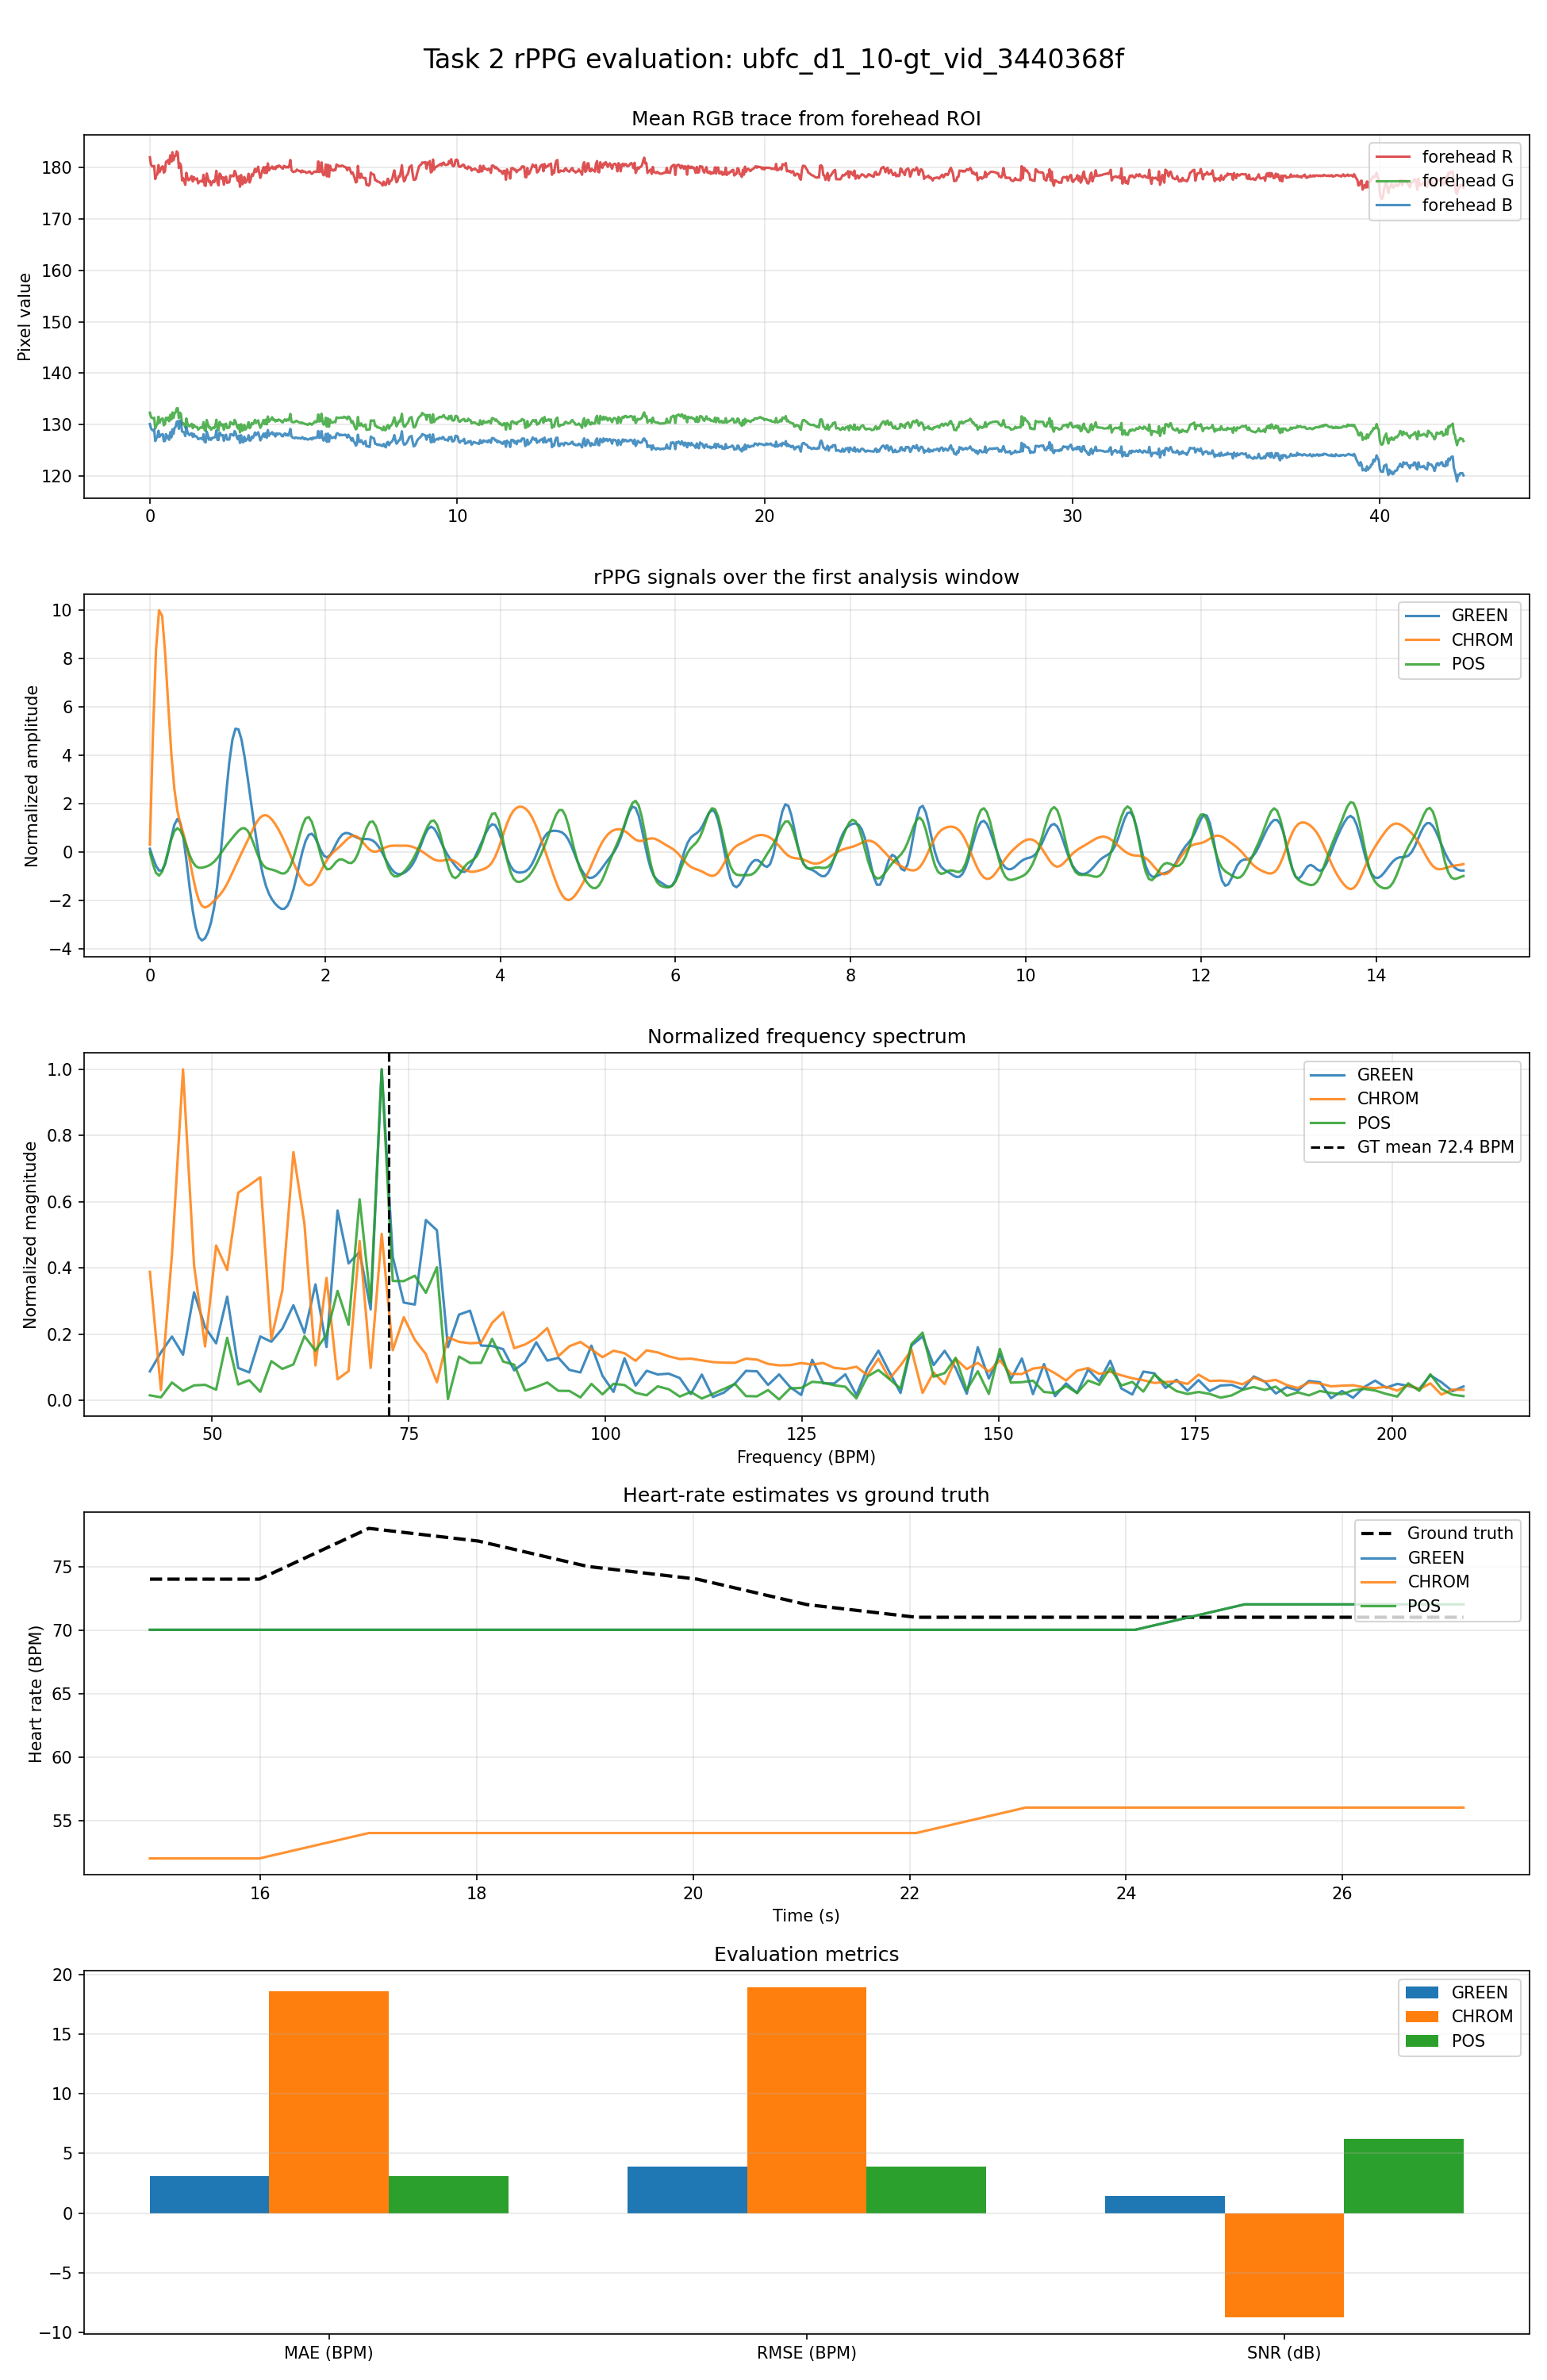

In [31]:
if SHOW_SAMPLE_VISUALIZATION and task2_manifest["items"]:
    first_processed = next((item for item in task2_manifest["items"] if item.get("status") == "processed"), None)
    if first_processed is not None:
        visualization_path = TASK2_OUTPUT_ROOT / first_processed["outputs"]["visualization_png"]
        if visualization_path.exists():
            display(Image(filename=str(visualization_path)))
